In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

P = np.array([
    [0.32062714, 0.23231163, 0.25632212, 0.19073911],
    [0.21009642, 0.28473236, 0.27851769, 0.22665352],
    [0.27058941, 0.21188479, 0.28881877, 0.22870704],
    [0.33945501, 0.30711288, 0.07056934, 0.28286277]
])

alphabet = ["A", "C", "G", "T"]
index = {nt:i for i, nt in enumerate(nucleotides)}

In [28]:
def generate_sequence(P, length, start_state):
    
    sequence = [start_state]
    current = nt_to_index[start_state]
    
    for _ in range(length - 1):
        index = np.random.choice(4, p=P[current])
        sequence.append(alphabet[index])
        current = index
        
    return ''.join(sequence)

In [29]:
seq_length = 1000
num_sequences = 10
sequences = []

for _ in range(num_sequences):
    sequences.append(generate_sequence(P, seq_length, start_state="A"))  

In [30]:
def count_dinucleotides(seq):
    counts = np.zeros((4,4)) 
    for i in range(len(seq) - 1):
        x = nt_to_index[seq[i]]
        y = nt_to_index[seq[i+1]]
        counts[x, y] += 1
    row_sums = counts.sum(axis=1, keepdims=True)
    return counts / row_sums

empirical_P = np.zeros((4,4))

for seq in sequences:
    empirical_P += count_dinucleotides(seq)

empirical_P /= num_sequences

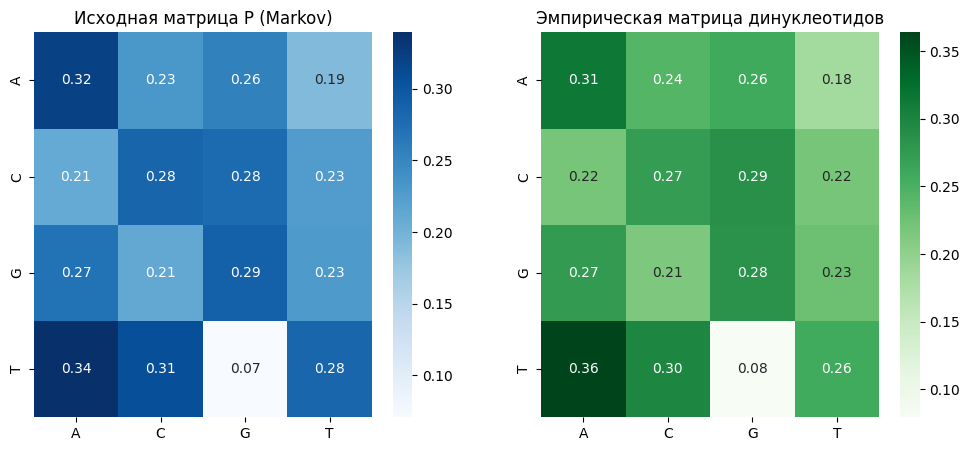

In [31]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(P, annot=True, fmt=".2f", xticklabels=alphabet, yticklabels=alphabet, cmap="Blues")
plt.title("Исходная матрица P (Markov)")

plt.subplot(1,2,2)
sns.heatmap(empirical_P, annot=True, fmt=".2f", xticklabels=alphabet, yticklabels=alphabet, cmap="Greens")
plt.title("Эмпирическая матрица динуклеотидов")

plt.show()